MULTI LINEAR REGRESSION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
data = pd.read_csv('sports_training_dataset.csv')
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'training_effectiveness' in numerical_cols:
    numerical_cols.remove('training_effectiveness')
X = data[numerical_cols]
y = data['training_effectiveness']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"--- Multi-Linear Regression Results ---")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

--- Multi-Linear Regression Results ---
R-squared Score: 1.0000
Mean Squared Error: 0.0000


PICKLE PACKAGE

In [ ]:
import pickle
pickle_filename = 'linear_regression_model.pkl'
with open(pickle_filename, 'wb') as file:
    pickle.dump(model, file)
print(pickle_filename)

linear_regression_model.pkl


In [ ]:
with open(pickle_filename, 'rb') as file:
    loaded_pickle_model = pickle.load(file)
loaded_pickle_y_pred = loaded_pickle_model.predict(X_test_scaled)
loaded_pickle_mse = mean_squared_error(y_test, loaded_pickle_y_pred)
loaded_pickle_r2 = r2_score(y_test, loaded_pickle_y_pred)
print(f"R-squared Score (loaded pickle model): {loaded_pickle_r2:.4f}")
print(f"Mean Squared Error (loaded pickle model): {loaded_pickle_mse:.4f}")


R-squared Score (loaded pickle model): 1.0000
Mean Squared Error (loaded pickle model): 0.0000


JOBLIB PACKAGE

In [20]:
import joblib
joblib_filename = 'linear_regression_model.joblib'
joblib.dump(model, joblib_filename)
print(joblib_filename)

linear_regression_model.joblib


In [22]:
loaded_joblib_model = joblib.load(joblib_filename)
loaded_joblib_y_pred = loaded_joblib_model.predict(X_test_scaled)
loaded_joblib_mse = mean_squared_error(y_test, loaded_joblib_y_pred)
loaded_joblib_r2 = r2_score(y_test, loaded_joblib_y_pred)
print(f"R-squared Score (loaded joblib model): {loaded_joblib_r2:.4f}")
print(f"Mean Squared Error (loaded joblib model): {loaded_joblib_mse:.4f}")

R-squared Score (loaded joblib model): 1.0000
Mean Squared Error (loaded joblib model): 0.0000


ONE HOT ENCODING

In [31]:
categorical_columns_to_encode = ['athlete_id']
encoded_df = pd.get_dummies(
    data,
    columns=categorical_columns_to_encode,
    drop_first=False
)
print("\nEncoded Dataset (explicit columns, drop_first=False):")
display(encoded_df.head())
print(f"\nShape of Encoded Dataset: {encoded_df.shape}")


Encoded Dataset (explicit columns, drop_first=False):


,age,height_cm,weight_kg,resting_heart_rate,max_heart_rate,VO2_max,cumulative_hits,cumulative_runs,training_hours_per_week,reaction_time_sec,...,athlete_id_ATH0991,athlete_id_ATH0992,athlete_id_ATH0993,athlete_id_ATH0994,athlete_id_ATH0995,athlete_id_ATH0996,athlete_id_ATH0997,athlete_id_ATH0998,athlete_id_ATH0999,athlete_id_ATH1000
0,21,150,78,94,160,42.703896,181,112,18,0.293652,...,False,False,False,False,False,False,False,False,False,False
1,18,194,72,70,198,47.268219,79,19,14,0.622542,...,False,False,False,False,False,False,False,False,False,False
2,27,162,59,67,187,48.038665,207,80,3,0.301498,...,False,False,False,False,False,False,False,False,False,False
3,29,153,74,86,213,37.404979,327,99,18,0.673995,...,False,False,False,False,False,False,False,False,False,False
4,25,150,81,94,218,47.935097,252,167,8,0.585994,...,False,False,False,False,False,False,False,False,False,False



Shape of Encoded Dataset: (1000, 1025)


In [33]:
output_filename = 'encoded_sports_training_dataset.csv'
encoded_df.to_csv(output_filename, index=False)
print(output_filename)

encoded_sports_training_dataset.csv


TRAIN TEST SPLIT

In [34]:
if 'training_effectiveness' in encoded_df.columns:
    X_encoded = encoded_df.drop('training_effectiveness', axis=1)
    y_encoded = encoded_df['training_effectiveness']
else:
    print("Error: 'training_effectiveness' column not found in encoded_df.")
    X_encoded = encoded_df.copy()
    y_encoded = pd.Series([])
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)
print(f"Shape of X_train_encoded: {X_train_encoded.shape}")
print(f"Shape of X_test_encoded: {X_test_encoded.shape}")
print(f"Shape of y_train_encoded: {y_train_encoded.shape}")
print(f"Shape of y_test_encoded: {y_test_encoded.shape}")

Shape of X_train_encoded: (800, 1024)
Shape of X_test_encoded: (200, 1024)
Shape of y_train_encoded: (800,)
Shape of y_test_encoded: (200,)


In [36]:
scaler_encoded = StandardScaler()
X_train_scaled_encoded = scaler_encoded.fit_transform(X_train_encoded)
X_test_scaled_encoded = scaler_encoded.transform(X_test_encoded)
print(f"Shape of scaled X_train: {X_train_scaled_encoded.shape}")
print(f"Shape of scaled X_test: {X_test_scaled_encoded.shape}")

Shape of scaled X_train: (800, 1024)
Shape of scaled X_test: (200, 1024)


1. LOGISTIC REGRESSION

--- Logistic Regression Results ---
Binary Classification Accuracy: 0.9800

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        94
           1       0.98      0.98      0.98       106

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



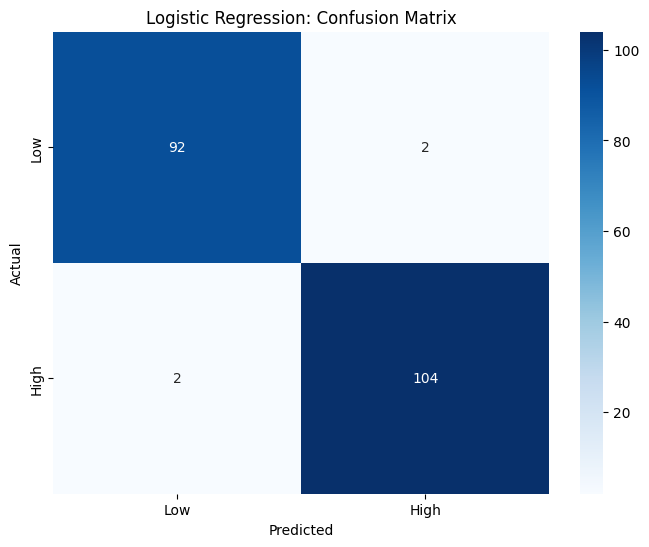

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('sports_training_dataset.csv')
median_val = data['training_effectiveness'].median()
data['effectiveness_class'] = (data['training_effectiveness'] > median_val).astype(int)
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
for col in ['training_effectiveness', 'effectiveness_class']:
    if col in numerical_cols: numerical_cols.remove(col)
X = data[numerical_cols]
y = data['effectiveness_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_model = LogisticRegression(max_iter=1000, solver='liblinear')
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Logistic Regression Results ---")
print(f"Binary Classification Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()